# Final Model Comparison

This notebook evaluates and visualizes test-set performance for:

- MPNet SentenceTransformer with the original/unretrained encoder
- MPNet SentenceTransformer with the retrained encoder
- TF-IDF + One-vs-Rest Logistic Regression



## 1. Setup


In [12]:
from pathlib import Path
import json
import time

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.sparse as sp
import seaborn as sns
from IPython.display import display
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    f1_score,
    hamming_loss,
    multilabel_confusion_matrix,
    precision_score,
    recall_score,
)
from sentence_transformers import SentenceTransformer

sns.set_theme(style="whitegrid")
pd.set_option("display.max_colwidth", 180)
pd.set_option("display.max_columns", 80)


In [13]:
def find_project_root(start: Path | None = None) -> Path:
    path = (start or Path.cwd()).resolve()
    for candidate in [path, *path.parents]:
        if (
            (candidate / "data" / "Restaurant_ABSA_processed.csv").exists()
            and (candidate / "outputs" / "MPNet" / "data_split.npz").exists()
        ):
            return candidate
    raise FileNotFoundError("Could not locate the project root.")


PROJECT_ROOT = find_project_root()
DATA_PATH = PROJECT_ROOT / "data" / "Restaurant_ABSA_processed.csv"
SPLIT_PATH = PROJECT_ROOT / "outputs" / "MPNet" / "data_split.npz"

MPNet_OUTPUT_DIR = PROJECT_ROOT / "outputs" / "MPNet"
MPNet_MODEL_DIR = PROJECT_ROOT / "models" / "mpnet"
MPNet_CLASSIFIER_DIR = MPNet_MODEL_DIR / "classifiers"

TFIDF_OUTPUT_DIR = PROJECT_ROOT / "outputs" / "TF-IDF"
TFIDF_MODEL_DIR = PROJECT_ROOT / "models" / "TF-IDF"
TFIDF_CLASSIFIER_DIR = TFIDF_MODEL_DIR / "classifiers"

FINAL_OUTPUT_DIR = PROJECT_ROOT / "outputs" / "final_comparison"
FINAL_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

ASPECT_COLUMNS = ["food", "price", "service", "ambiance", "miscellaneous"]
TFIDF_ASPECT_COLUMNS = ["food", "service", "price", "ambiance", "miscellaneous"]

required_paths = [
    DATA_PATH,
    SPLIT_PATH,
    MPNet_CLASSIFIER_DIR / "unretrained" / "model.joblib",
    MPNet_CLASSIFIER_DIR / "unretrained" / "metadata.json",
    MPNet_CLASSIFIER_DIR / "retrained" / "model.joblib",
    MPNet_CLASSIFIER_DIR / "retrained" / "metadata.json",
    TFIDF_OUTPUT_DIR / "X_test_tfidf.npz",
    TFIDF_CLASSIFIER_DIR / "tfidf_ovr_logreg.joblib",
    TFIDF_CLASSIFIER_DIR / "tfidf_metadata.json",
]

missing_paths = [path for path in required_paths if not path.exists()]
if missing_paths:
    raise FileNotFoundError("Missing required artifacts:\n" + "\n".join(map(str, missing_paths)))

print("Project root:", PROJECT_ROOT)
print("Final outputs:", FINAL_OUTPUT_DIR)


Project root: D:\ZB\Code\UIT\CS221
Final outputs: D:\ZB\Code\UIT\CS221\outputs\final_comparison


## 2. Load Test Set


In [14]:
df = pd.read_csv(DATA_PATH).dropna(subset=["review_en"]).reset_index(drop=True)
split = np.load(SPLIT_PATH)
test_idx = split["test_idx"]

test_df = df.iloc[test_idx].copy().reset_index().rename(columns={"index": "source_row"})
test_texts = test_df["review_en"].astype(str).tolist()
y_test = test_df[ASPECT_COLUMNS].to_numpy(dtype=np.int8)

print(f"Test samples: {len(test_df)}")
display(test_df[["source_row", "review_en", *ASPECT_COLUMNS]].head())


Test samples: 160


,source_row,review_en,food,price,service,ambiance,miscellaneous
0,692,although the price of the product has increased the quality and taste have not changed,1,1,0,0,0
1,779,the restaurant is very clean and the ambience is very nice,0,0,0,1,0
2,63,the side dishes are not very good but the service is good,1,0,1,0,0
3,532,from today it is my favorite restaurant because the service here is very bad and the price of everything is very high,0,1,1,0,0
4,66,best chicken pressure the price of 120 rupees seemed right to me,1,1,0,0,0


## 3. Shared Evaluation Helpers


In [15]:
def labels_to_text(row, aspect_cols=ASPECT_COLUMNS) -> str:
    row = np.asarray(row).astype(bool)
    labels = np.array(aspect_cols)[row]
    return ", ".join(labels) if len(labels) else "None"


def apply_thresholds(probabilities: np.ndarray, thresholds: dict, aspect_cols: list[str]) -> np.ndarray:
    predictions = np.zeros_like(probabilities, dtype=np.int8)
    for index, aspect in enumerate(aspect_cols):
        predictions[:, index] = (probabilities[:, index] >= thresholds[aspect]).astype(np.int8)

    empty_rows = np.flatnonzero(predictions.sum(axis=1) == 0)
    for row in empty_rows:
        predictions[row, np.argmax(probabilities[row])] = 1
    return predictions


def reorder_columns(matrix: np.ndarray, from_cols: list[str], to_cols: list[str]) -> np.ndarray:
    positions = [from_cols.index(col) for col in to_cols]
    return matrix[:, positions]


def evaluate_predictions(model_name: str, y_true: np.ndarray, y_pred: np.ndarray, seconds: float | None = None) -> dict:
    per_aspect_f1 = f1_score(y_true, y_pred, average=None, zero_division=0)
    metrics = {
        "model": model_name,
        "macro_f1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "micro_f1": f1_score(y_true, y_pred, average="micro", zero_division=0),
        "samples_f1": f1_score(y_true, y_pred, average="samples", zero_division=0),
        "precision_micro": precision_score(y_true, y_pred, average="micro", zero_division=0),
        "recall_micro": recall_score(y_true, y_pred, average="micro", zero_division=0),
        "exact_match_ratio": accuracy_score(y_true, y_pred),
        "hamming_loss": hamming_loss(y_true, y_pred),
        "mean_predicted_labels": y_pred.sum(axis=1).mean(),
        "mean_true_labels": y_true.sum(axis=1).mean(),
    }
    if seconds is not None:
        metrics["seconds"] = seconds
        metrics["milliseconds_per_review"] = seconds * 1000 / len(y_true)

    for index, aspect in enumerate(ASPECT_COLUMNS):
        metrics[f"{aspect}_f1"] = per_aspect_f1[index]
    return metrics


def build_prediction_frame(model_name: str, probabilities: np.ndarray, predictions: np.ndarray) -> pd.DataFrame:
    output = test_df[["source_row", "review_en", "review_cleaned"]].copy()
    output["model"] = model_name
    output["true_aspects"] = [labels_to_text(row) for row in y_test]
    output["predicted_aspects"] = [labels_to_text(row) for row in predictions]
    output["exact_match"] = (predictions == y_test).all(axis=1)
    output["true_label_count"] = y_test.sum(axis=1)
    output["predicted_label_count"] = predictions.sum(axis=1)

    for index, aspect in enumerate(ASPECT_COLUMNS):
        output[f"true_{aspect}"] = y_test[:, index]
        output[f"pred_{aspect}"] = predictions[:, index]
        output[f"prob_{aspect}"] = probabilities[:, index]

    output["max_probability"] = probabilities.max(axis=1)
    output["mean_true_aspect_probability"] = [
        probabilities[row_index, y_test[row_index].astype(bool)].mean()
        if y_test[row_index].any()
        else np.nan
        for row_index in range(len(y_test))
    ]
    return output


## 4. Evaluate MPNet Models


In [16]:
def evaluate_mpnet_bundle(bundle_name: str) -> dict:
    bundle_dir = MPNet_CLASSIFIER_DIR / bundle_name
    classifier = joblib.load(bundle_dir / "model.joblib")
    with (bundle_dir / "metadata.json").open(encoding="utf-8") as file:
        metadata = json.load(file)

    aspect_cols = metadata["aspect_cols"]
    encoder_path = PROJECT_ROOT / metadata["encoder_path"]
    encoder = SentenceTransformer(str(encoder_path))

    start = time.perf_counter()
    embeddings = encoder.encode(
        test_texts,
        batch_size=metadata.get("batch_size", 32),
        normalize_embeddings=metadata.get("normalize_embeddings", True),
        convert_to_numpy=True,
        show_progress_bar=True,
    )
    probabilities = classifier.predict_proba(embeddings)
    seconds = time.perf_counter() - start

    predictions = apply_thresholds(probabilities, metadata["thresholds"], aspect_cols)
    probabilities = reorder_columns(probabilities, aspect_cols, ASPECT_COLUMNS)
    predictions = reorder_columns(predictions, aspect_cols, ASPECT_COLUMNS)

    model_name = f"MPNet {bundle_name}"
    return {
        "model_name": model_name,
        "metadata": metadata,
        "probabilities": probabilities,
        "predictions": predictions,
        "metrics": evaluate_predictions(model_name, y_test, predictions, seconds=seconds),
        "report": classification_report(
            y_test,
            predictions,
            target_names=ASPECT_COLUMNS,
            output_dict=True,
            zero_division=0,
        ),
        "prediction_frame": build_prediction_frame(model_name, probabilities, predictions),
    }


mpnet_results = {
    "MPNet unretrained": evaluate_mpnet_bundle("unretrained"),
    "MPNet retrained": evaluate_mpnet_bundle("retrained"),
}


Batches: 100%|██████████| 5/5 [00:03<00:00,  1.64it/s]


## 5. Evaluate TF-IDF Model


In [17]:
def evaluate_tfidf_model() -> dict:
    X_test_tfidf = sp.load_npz(TFIDF_OUTPUT_DIR / "X_test_tfidf.npz")
    classifier = joblib.load(TFIDF_CLASSIFIER_DIR / "tfidf_ovr_logreg.joblib")
    with (TFIDF_CLASSIFIER_DIR / "tfidf_metadata.json").open(encoding="utf-8") as file:
        metadata = json.load(file)

    start = time.perf_counter()
    probabilities = classifier.predict_proba(X_test_tfidf)
    seconds = time.perf_counter() - start

    predictions = apply_thresholds(probabilities, metadata["thresholds"], TFIDF_ASPECT_COLUMNS)
    probabilities = reorder_columns(probabilities, TFIDF_ASPECT_COLUMNS, ASPECT_COLUMNS)
    predictions = reorder_columns(predictions, TFIDF_ASPECT_COLUMNS, ASPECT_COLUMNS)

    model_name = "TF-IDF"
    return {
        "model_name": model_name,
        "metadata": metadata,
        "probabilities": probabilities,
        "predictions": predictions,
        "metrics": evaluate_predictions(model_name, y_test, predictions, seconds=seconds),
        "report": classification_report(
            y_test,
            predictions,
            target_names=ASPECT_COLUMNS,
            output_dict=True,
            zero_division=0,
        ),
        "prediction_frame": build_prediction_frame(model_name, probabilities, predictions),
    }


tfidf_result = evaluate_tfidf_model()
all_results = {**mpnet_results, "TF-IDF": tfidf_result}


## 6. Overall Metrics


In [18]:
comparison_df = (
    pd.DataFrame([result["metrics"] for result in all_results.values()])
    .sort_values("macro_f1", ascending=False)
    .reset_index(drop=True)
)

comparison_df.to_csv(FINAL_OUTPUT_DIR / "final_model_comparison.csv", index=False)
display(comparison_df)


,model,macro_f1,micro_f1,samples_f1,precision_micro,recall_micro,exact_match_ratio,hamming_loss,mean_predicted_labels,mean_true_labels,seconds,milliseconds_per_review,food_f1,price_f1,service_f1,ambiance_f1,miscellaneous_f1
0,MPNet retrained,0.887309,0.955414,0.953542,0.943396,0.967742,0.86875,0.03500,1.98750,1.9375,3.069654,19.185336,0.967509,1.000000,0.939759,0.945946,0.583333
1,MPNet unretrained,0.781933,0.864458,0.872708,0.810734,0.925806,0.61250,0.11250,2.21250,1.9375,3.066040,19.162748,0.927336,0.958084,0.939759,0.761905,0.322581
2,TF-IDF,0.773553,0.906404,0.899167,0.923077,0.890323,0.73125,0.07125,1.86875,1.9375,0.001552,0.009702,0.936803,0.948571,0.938272,0.794118,0.250000


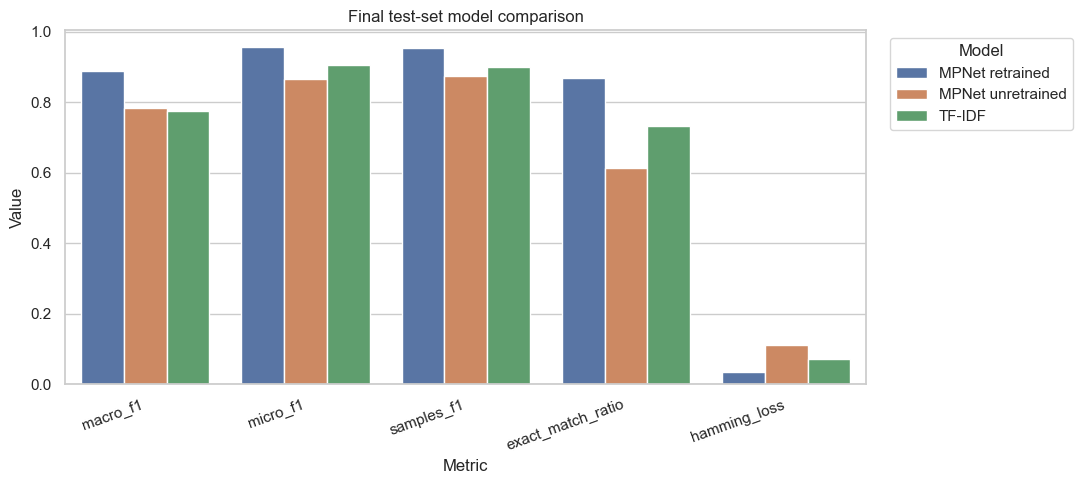

In [19]:
main_metrics = [
    "macro_f1",
    "micro_f1",
    "samples_f1",
    "exact_match_ratio",
    "hamming_loss",
]

plot_df = comparison_df.melt(
    id_vars="model",
    value_vars=main_metrics,
    var_name="metric",
    value_name="value",
)

plt.figure(figsize=(11, 5))
sns.barplot(data=plot_df, x="metric", y="value", hue="model")
plt.title("Final test-set model comparison")
plt.xlabel("Metric")
plt.ylabel("Value")
plt.xticks(rotation=20, ha="right")
plt.legend(title="Model", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.savefig(FINAL_OUTPUT_DIR / "overall_metrics_comparison.png", dpi=160)
plt.show()


,model,seconds,milliseconds_per_review
0,MPNet retrained,3.069654,19.185336
1,MPNet unretrained,3.066040,19.162748
2,TF-IDF,0.001552,0.009702


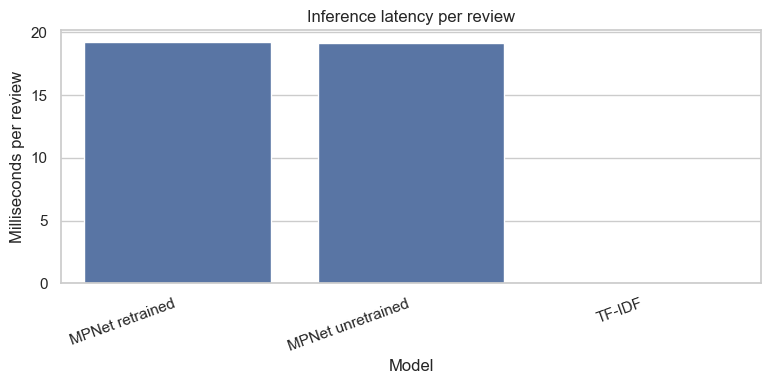

In [20]:
speed_cols = ["model", "seconds", "milliseconds_per_review"]
speed_df = comparison_df[[col for col in speed_cols if col in comparison_df.columns]].copy()
display(speed_df)

plt.figure(figsize=(8, 4))
sns.barplot(data=speed_df, x="model", y="milliseconds_per_review")
plt.title("Inference latency per review")
plt.xlabel("Model")
plt.ylabel("Milliseconds per review")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.savefig(FINAL_OUTPUT_DIR / "latency_comparison.png", dpi=160)
plt.show()


## 7. Per-Aspect F1 Comparison


model,MPNet retrained,MPNet unretrained,TF-IDF
aspect,,,
food,0.967509,0.927336,0.936803
price,1.000000,0.958084,0.948571
service,0.939759,0.939759,0.938272
ambiance,0.945946,0.761905,0.794118
miscellaneous,0.583333,0.322581,0.250000


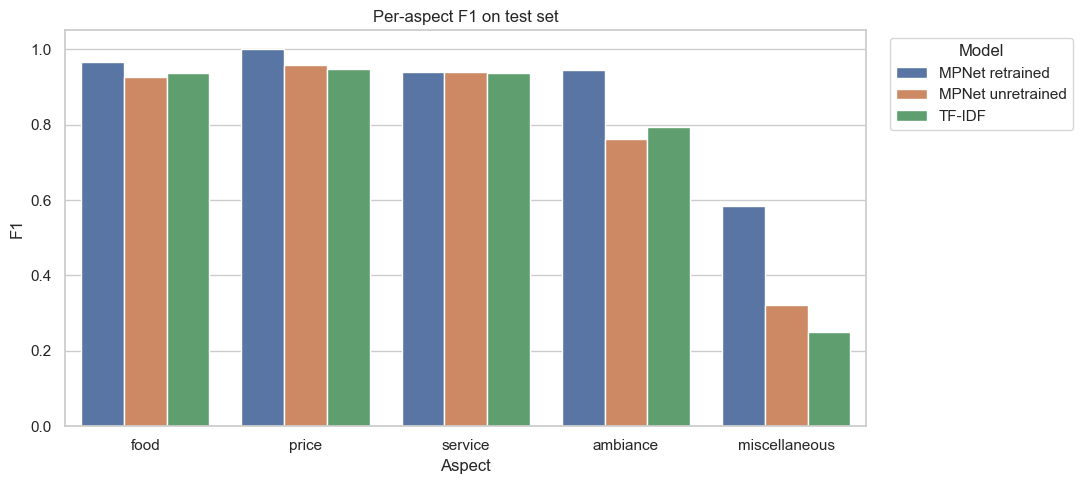

In [21]:
aspect_f1_cols = [f"{aspect}_f1" for aspect in ASPECT_COLUMNS]
aspect_f1_df = comparison_df[["model", *aspect_f1_cols]].melt(
    id_vars="model",
    var_name="aspect",
    value_name="f1",
)
aspect_f1_df["aspect"] = aspect_f1_df["aspect"].str.replace("_f1", "", regex=False)

aspect_f1_df.to_csv(FINAL_OUTPUT_DIR / "per_aspect_f1_comparison.csv", index=False)
display(aspect_f1_df.pivot(index="aspect", columns="model", values="f1").loc[ASPECT_COLUMNS])

plt.figure(figsize=(11, 5))
sns.barplot(data=aspect_f1_df, x="aspect", y="f1", hue="model")
plt.title("Per-aspect F1 on test set")
plt.xlabel("Aspect")
plt.ylabel("F1")
plt.ylim(0, 1.05)
plt.legend(title="Model", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.savefig(FINAL_OUTPUT_DIR / "per_aspect_f1_comparison.png", dpi=160)
plt.show()


## 8. Classification Reports


In [22]:
report_frames = []
for model_name, result in all_results.items():
    report = pd.DataFrame(result["report"]).T.reset_index().rename(columns={"index": "label"})
    report.insert(0, "model", model_name)
    report_frames.append(report)

reports_df = pd.concat(report_frames, ignore_index=True)
reports_df.to_csv(FINAL_OUTPUT_DIR / "classification_reports.csv", index=False)

display(
    reports_df[
        reports_df["label"].isin(ASPECT_COLUMNS + ["micro avg", "macro avg", "samples avg"])
    ].round(4)
)


,model,label,precision,recall,f1-score,support
0,MPNet unretrained,food,0.8645,1.0000,0.9273,134.0
1,MPNet unretrained,price,0.9756,0.9412,0.9581,85.0
2,MPNet unretrained,service,0.9512,0.9286,0.9398,42.0
3,MPNet unretrained,ambiance,0.8571,0.6857,0.7619,35.0
4,MPNet unretrained,miscellaneous,0.2083,0.7143,0.3226,14.0
5,MPNet unretrained,micro avg,0.8107,0.9258,0.8645,310.0
6,MPNet unretrained,macro avg,0.7714,0.8539,0.7819,310.0
8,MPNet unretrained,samples avg,0.8510,0.9281,0.8727,310.0
9,MPNet retrained,food,0.9371,1.0000,0.9675,134.0
10,MPNet retrained,price,1.0000,1.0000,1.0000,85.0


## 9. Confusion Matrices


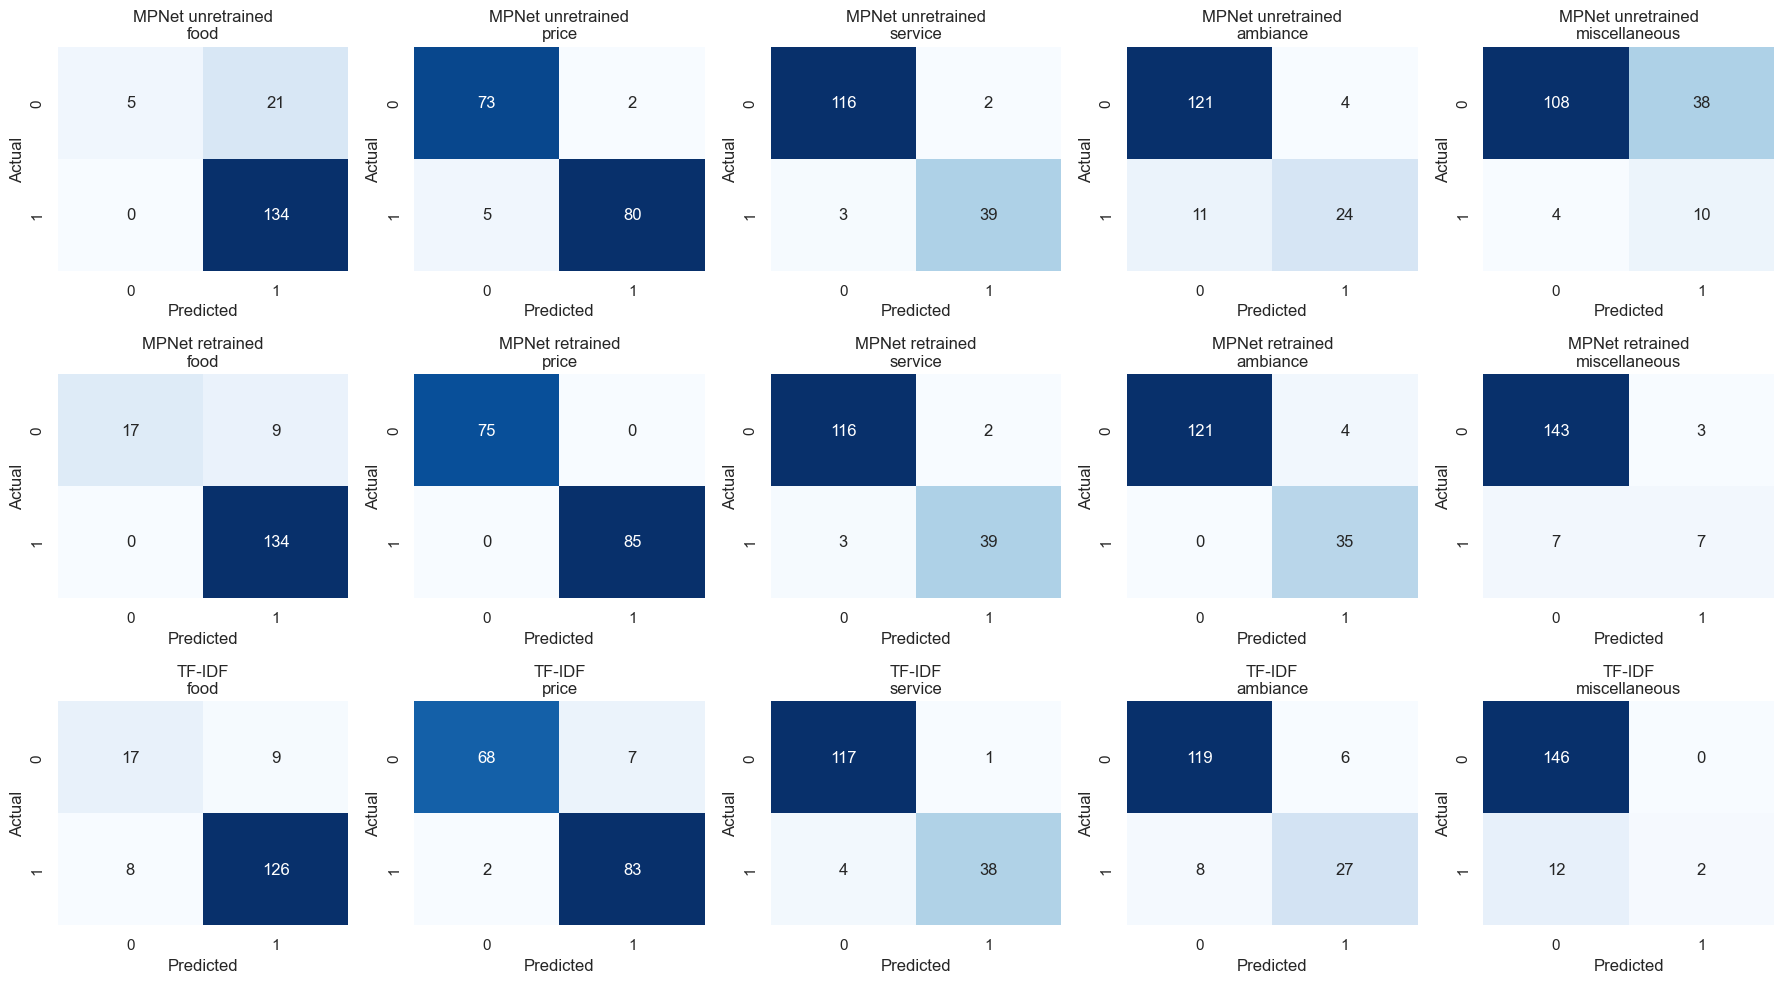

In [23]:
fig, axes = plt.subplots(len(all_results), len(ASPECT_COLUMNS), figsize=(18, 10))

for row_index, (model_name, result) in enumerate(all_results.items()):
    matrices = multilabel_confusion_matrix(y_test, result["predictions"])
    for col_index, aspect in enumerate(ASPECT_COLUMNS):
        ax = axes[row_index, col_index]
        sns.heatmap(
            matrices[col_index],
            annot=True,
            fmt="d",
            cmap="Blues",
            cbar=False,
            ax=ax,
        )
        ax.set_title(f"{model_name}\n{aspect}")
        ax.set_xlabel("Predicted")
        ax.set_ylabel("Actual")

plt.tight_layout()
plt.savefig(FINAL_OUTPUT_DIR / "confusion_matrices.png", dpi=160)
plt.show()


## 10. Exact-Match Overlap


In [24]:
exact_match_df = test_df[["source_row", "review_en", "review_cleaned"]].copy()
exact_match_df["true_aspects"] = [labels_to_text(row) for row in y_test]

for model_name, result in all_results.items():
    key = model_name.lower().replace(" ", "_").replace("-", "")
    exact_match_df[f"{key}_predicted_aspects"] = [
        labels_to_text(row) for row in result["predictions"]
    ]
    exact_match_df[f"{key}_exact_match"] = (
        result["predictions"] == y_test
    ).all(axis=1)

exact_match_cols = [col for col in exact_match_df.columns if col.endswith("_exact_match")]
overlap_summary = (
    exact_match_df[exact_match_cols]
    .value_counts()
    .rename_axis(exact_match_cols)
    .reset_index(name="sample_count")
)

exact_match_df.to_csv(FINAL_OUTPUT_DIR / "sample_level_predictions.csv", index=False)
overlap_summary.to_csv(FINAL_OUTPUT_DIR / "exact_match_overlap_summary.csv", index=False)

display(overlap_summary)


,mpnet_unretrained_exact_match,mpnet_retrained_exact_match,tfidf_exact_match,sample_count
0,True,True,True,82
1,False,True,True,26
2,False,True,False,21
3,True,True,False,10
4,False,False,False,9
5,False,False,True,6
6,True,False,True,3
7,True,False,False,3


## 11. Samples Correct In MPNet But Wrong In TF-IDF


In [25]:
mpnet_key = "mpnet_retrained"
tfidf_key = "tfidf"

mpnet_correct_tfidf_wrong = exact_match_df[
    exact_match_df[f"{mpnet_key}_exact_match"]
    & ~exact_match_df[f"{tfidf_key}_exact_match"]
].copy()

tfidf_correct_mpnet_wrong = exact_match_df[
    ~exact_match_df[f"{mpnet_key}_exact_match"]
    & exact_match_df[f"{tfidf_key}_exact_match"]
].copy()

comparison_sample_cols = [
    "source_row",
    "review_en",
    "true_aspects",
    f"{mpnet_key}_predicted_aspects",
    f"{tfidf_key}_predicted_aspects",
]

mpnet_correct_tfidf_wrong[comparison_sample_cols].to_csv(
    FINAL_OUTPUT_DIR / "mpnet_retrained_correct_tfidf_wrong.csv",
    index=False,
)
tfidf_correct_mpnet_wrong[comparison_sample_cols].to_csv(
    FINAL_OUTPUT_DIR / "tfidf_correct_mpnet_retrained_wrong.csv",
    index=False,
)

print(f"MPNet retrained correct, TF-IDF wrong: {len(mpnet_correct_tfidf_wrong)}")
display(mpnet_correct_tfidf_wrong[comparison_sample_cols].head(20))


MPNet retrained correct, TF-IDF wrong: 31


,source_row,review_en,true_aspects,mpnet_retrained_predicted_aspects,tfidf_predicted_aspects
5,750,the food here is not very good and the workers are lazy,"food, service","food, service",food
9,625,their kitchen is not very nice so people cannot enjoy the taste of the food as much,"food, ambiance","food, ambiance",food
11,285,there is no extra decoration and the service is decent,"service, ambiance","service, ambiance",service
17,630,the biryani rice was fluffy but the meat was tough,food,food,"food, price"
25,30,the biryani rice was fluffy and fluffy but the meat was tough,food,food,"food, price"
43,685,there are many items that are good and the company cares for the environment,"food, ambiance","food, ambiance",ambiance
45,649,awful halim the environment is also bad,"food, ambiance","food, ambiance",ambiance
48,737,the burger patty is thicker than a regular burger and because of that it is bigger,food,food,"food, price"
55,367,the taste of the sushi was not that great but the atmosphere of the restaurant was so good that i would go there again,"food, ambiance","food, ambiance",ambiance
61,473,every item tasted amazing and their workmanship was better than other places,"food, service","food, service",food


In [26]:
print(f"TF-IDF correct, MPNet retrained wrong: {len(tfidf_correct_mpnet_wrong)}")
display(tfidf_correct_mpnet_wrong[comparison_sample_cols].head(20))


TF-IDF correct, MPNet retrained wrong: 9


,source_row,review_en,true_aspects,mpnet_retrained_predicted_aspects,tfidf_predicted_aspects
12,634,schizlingter is a type of food that is served hot and fresh,"food, service",food,"food, service"
51,109,the location of the restaurant is good and the price of the food is also low,"price, miscellaneous","price, ambiance, miscellaneous","price, miscellaneous"
74,31,as for the beef the test was very good but the name kalabuna was not right,food,"food, miscellaneous",food
85,344,all the staff looked very professional but their service was not that good,service,"food, service",service
104,76,the restaurant is small but expensive,"price, ambiance","price, ambiance, miscellaneous","price, ambiance"
106,351,the decoration of the restaurant is very unique and i think it has the best atmosphere,ambiance,"food, ambiance",ambiance
125,254,the decoration was very different and the atmosphere was very lively,ambiance,"food, ambiance",ambiance
152,365,food prices are lower than other nearby places but the food is very expensive,price,"price, miscellaneous",price
158,512,the sweets were disgusting and i hated their use,"food, service",food,"food, service"


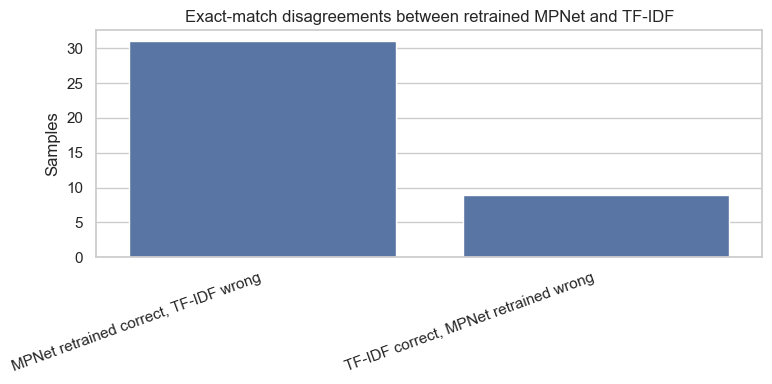

,case,sample_count
0,"MPNet retrained correct, TF-IDF wrong",31
1,"TF-IDF correct, MPNet retrained wrong",9


In [27]:
counts = pd.DataFrame(
    {
        "case": [
            "MPNet retrained correct, TF-IDF wrong",
            "TF-IDF correct, MPNet retrained wrong",
        ],
        "sample_count": [
            len(mpnet_correct_tfidf_wrong),
            len(tfidf_correct_mpnet_wrong),
        ],
    }
)

plt.figure(figsize=(8, 4))
sns.barplot(data=counts, x="case", y="sample_count")
plt.title("Exact-match disagreements between retrained MPNet and TF-IDF")
plt.xlabel("")
plt.ylabel("Samples")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.savefig(FINAL_OUTPUT_DIR / "mpnet_tfidf_disagreement_counts.png", dpi=160)
plt.show()

display(counts)


## 12. Aspect-Level Error Differences


In [28]:
error_rows = []
for model_name, result in all_results.items():
    predictions = result["predictions"]
    for index, aspect in enumerate(ASPECT_COLUMNS):
        y_true_col = y_test[:, index]
        y_pred_col = predictions[:, index]
        false_positive = int(((y_true_col == 0) & (y_pred_col == 1)).sum())
        false_negative = int(((y_true_col == 1) & (y_pred_col == 0)).sum())
        true_positive = int(((y_true_col == 1) & (y_pred_col == 1)).sum())
        true_negative = int(((y_true_col == 0) & (y_pred_col == 0)).sum())
        error_rows.append(
            {
                "model": model_name,
                "aspect": aspect,
                "true_positive": true_positive,
                "false_positive": false_positive,
                "false_negative": false_negative,
                "true_negative": true_negative,
            }
        )

error_df = pd.DataFrame(error_rows)
error_df.to_csv(FINAL_OUTPUT_DIR / "aspect_error_counts.csv", index=False)
display(error_df)


,model,aspect,true_positive,false_positive,false_negative,true_negative
0,MPNet unretrained,food,134,21,0,5
1,MPNet unretrained,price,80,2,5,73
2,MPNet unretrained,service,39,2,3,116
3,MPNet unretrained,ambiance,24,4,11,121
4,MPNet unretrained,miscellaneous,10,38,4,108
5,MPNet retrained,food,134,9,0,17
6,MPNet retrained,price,85,0,0,75
7,MPNet retrained,service,39,2,3,116
8,MPNet retrained,ambiance,35,4,0,121
9,MPNet retrained,miscellaneous,7,3,7,143


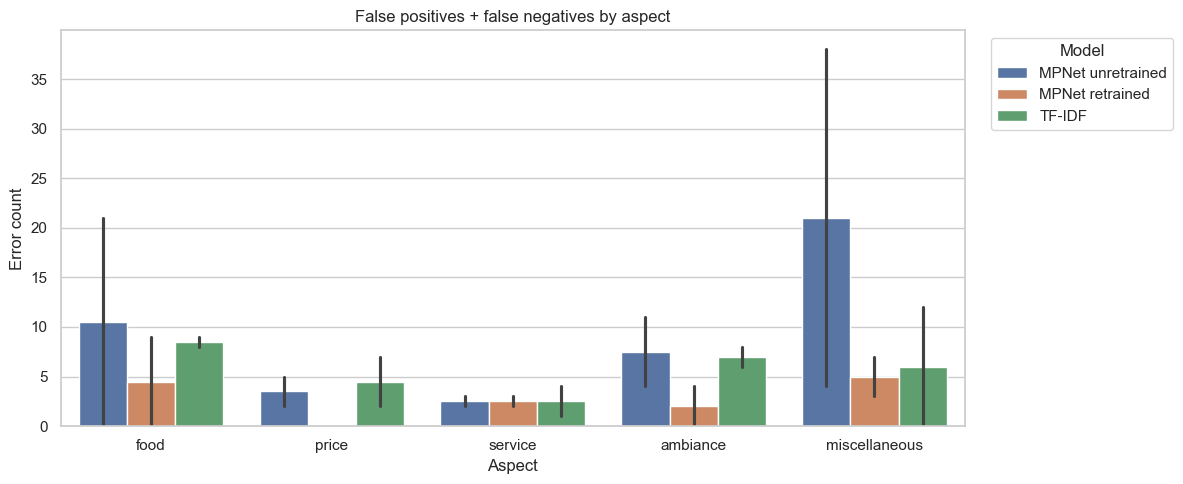

In [29]:
error_plot_df = error_df.melt(
    id_vars=["model", "aspect"],
    value_vars=["false_positive", "false_negative"],
    var_name="error_type",
    value_name="count",
)

plt.figure(figsize=(12, 5))
sns.barplot(data=error_plot_df, x="aspect", y="count", hue="model")
plt.title("False positives + false negatives by aspect")
plt.xlabel("Aspect")
plt.ylabel("Error count")
plt.legend(title="Model", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.savefig(FINAL_OUTPUT_DIR / "aspect_total_error_comparison.png", dpi=160)
plt.show()


## 13. Best And Worst Cases

Best cases are exact-match samples where the model assigns high average probability to the true aspects.

Worst cases are non-exact-match samples ranked by:

1. more label errors first
2. higher wrong-confidence first
3. lower true-aspect confidence first

These tables are useful for explaining where each model is reliable and where it fails.


In [30]:
def aspect_list_from_binary(row: np.ndarray) -> list[str]:
    return [aspect for aspect, value in zip(ASPECT_COLUMNS, row.astype(int)) if value == 1]


def build_case_analysis_frame(model_name: str, result: dict) -> pd.DataFrame:
    probabilities = result["probabilities"]
    predictions = result["predictions"]

    rows = []
    for row_index in range(len(test_df)):
        true_row = y_test[row_index].astype(int)
        pred_row = predictions[row_index].astype(int)
        prob_row = probabilities[row_index]

        false_positive_aspects = [
            aspect
            for aspect_index, aspect in enumerate(ASPECT_COLUMNS)
            if true_row[aspect_index] == 0 and pred_row[aspect_index] == 1
        ]
        false_negative_aspects = [
            aspect
            for aspect_index, aspect in enumerate(ASPECT_COLUMNS)
            if true_row[aspect_index] == 1 and pred_row[aspect_index] == 0
        ]
        true_aspect_mask = true_row.astype(bool)
        predicted_aspect_mask = pred_row.astype(bool)
        wrong_predicted_mask = (true_row == 0) & (pred_row == 1)

        mean_true_probability = (
            float(prob_row[true_aspect_mask].mean())
            if true_aspect_mask.any()
            else np.nan
        )
        min_true_probability = (
            float(prob_row[true_aspect_mask].min())
            if true_aspect_mask.any()
            else np.nan
        )
        mean_predicted_probability = (
            float(prob_row[predicted_aspect_mask].mean())
            if predicted_aspect_mask.any()
            else np.nan
        )
        max_wrong_probability = (
            float(prob_row[wrong_predicted_mask].max())
            if wrong_predicted_mask.any()
            else 0.0
        )

        rows.append(
            {
                "model": model_name,
                "source_row": int(test_df.loc[row_index, "source_row"]),
                "review_en": test_df.loc[row_index, "review_en"],
                "true_aspects": labels_to_text(true_row),
                "predicted_aspects": labels_to_text(pred_row),
                "exact_match": bool((true_row == pred_row).all()),
                "label_error_count": int(np.abs(true_row - pred_row).sum()),
                "false_positive_aspects": ", ".join(false_positive_aspects) or "None",
                "false_negative_aspects": ", ".join(false_negative_aspects) or "None",
                "mean_true_probability": mean_true_probability,
                "min_true_probability": min_true_probability,
                "mean_predicted_probability": mean_predicted_probability,
                "max_wrong_probability": max_wrong_probability,
            }
        )

    return pd.DataFrame(rows)


case_frames = [
    build_case_analysis_frame(model_name, result)
    for model_name, result in all_results.items()
]
case_analysis_df = pd.concat(case_frames, ignore_index=True)
case_analysis_df.to_csv(FINAL_OUTPUT_DIR / "case_analysis_all_models.csv", index=False)

display(case_analysis_df.head())


,model,source_row,review_en,true_aspects,predicted_aspects,exact_match,label_error_count,false_positive_aspects,false_negative_aspects,mean_true_probability,min_true_probability,mean_predicted_probability,max_wrong_probability
0,MPNet unretrained,692,although the price of the product has increased the quality and taste have not changed,"food, price","food, price",True,0,None,None,0.923444,0.855752,0.923444,0.000000
1,MPNet unretrained,779,the restaurant is very clean and the ambience is very nice,ambiance,"food, ambiance",False,1,food,None,0.990832,0.990832,0.675229,0.359625
2,MPNet unretrained,63,the side dishes are not very good but the service is good,"food, service","food, service",True,0,None,None,0.868047,0.760536,0.868047,0.000000
3,MPNet unretrained,532,from today it is my favorite restaurant because the service here is very bad and the price of everything is very high,"price, service","food, service, miscellaneous",False,3,"food, miscellaneous",price,0.491358,0.398886,0.568421,0.689761
4,MPNet unretrained,66,best chicken pressure the price of 120 rupees seemed right to me,"food, price","food, price",True,0,None,None,0.987135,0.980139,0.987135,0.000000


In [31]:
best_case_frames = []
worst_case_frames = []

for model_name in all_results:
    model_cases = case_analysis_df[case_analysis_df["model"] == model_name].copy()

    best_cases = (
        model_cases[model_cases["exact_match"]]
        .sort_values(
            ["mean_true_probability", "min_true_probability"],
            ascending=[False, False],
        )
        .head(15)
    )
    worst_cases = (
        model_cases[~model_cases["exact_match"]]
        .sort_values(
            [
                "label_error_count",
                "max_wrong_probability",
                "mean_true_probability",
            ],
            ascending=[False, False, True],
        )
        .head(15)
    )

    safe_name = model_name.lower().replace(" ", "_").replace("-", "")
    best_cases.to_csv(FINAL_OUTPUT_DIR / f"{safe_name}_best_cases.csv", index=False)
    worst_cases.to_csv(FINAL_OUTPUT_DIR / f"{safe_name}_worst_cases.csv", index=False)

    best_case_frames.append(best_cases)
    worst_case_frames.append(worst_cases)

all_best_cases = pd.concat(best_case_frames, ignore_index=True)
all_worst_cases = pd.concat(worst_case_frames, ignore_index=True)

all_best_cases.to_csv(FINAL_OUTPUT_DIR / "best_cases_all_models.csv", index=False)
all_worst_cases.to_csv(FINAL_OUTPUT_DIR / "worst_cases_all_models.csv", index=False)

print("Saved best/worst case files to:", FINAL_OUTPUT_DIR)


Saved best/worst case files to: D:\ZB\Code\UIT\CS221\outputs\final_comparison


In [32]:
case_summary = (
    case_analysis_df
    .groupby("model")
    .agg(
        exact_matches=("exact_match", "sum"),
        total_samples=("exact_match", "size"),
        mean_label_errors=("label_error_count", "mean"),
        max_label_errors=("label_error_count", "max"),
        mean_true_probability=("mean_true_probability", "mean"),
        mean_predicted_probability=("mean_predicted_probability", "mean"),
        mean_max_wrong_probability=("max_wrong_probability", "mean"),
    )
    .reset_index()
)
case_summary["exact_match_ratio"] = (
    case_summary["exact_matches"] / case_summary["total_samples"]
)
case_summary.to_csv(FINAL_OUTPUT_DIR / "case_analysis_summary.csv", index=False)
display(case_summary.round(4))


,model,exact_matches,total_samples,mean_label_errors,max_label_errors,mean_true_probability,mean_predicted_probability,mean_max_wrong_probability,exact_match_ratio
0,MPNet retrained,139,160,0.1750,3,0.9471,0.9476,0.0593,0.8688
1,MPNet unretrained,98,160,0.5625,3,0.8554,0.8401,0.1619,0.6125
2,TF-IDF,117,160,0.3562,2,0.8047,0.8572,0.0928,0.7312


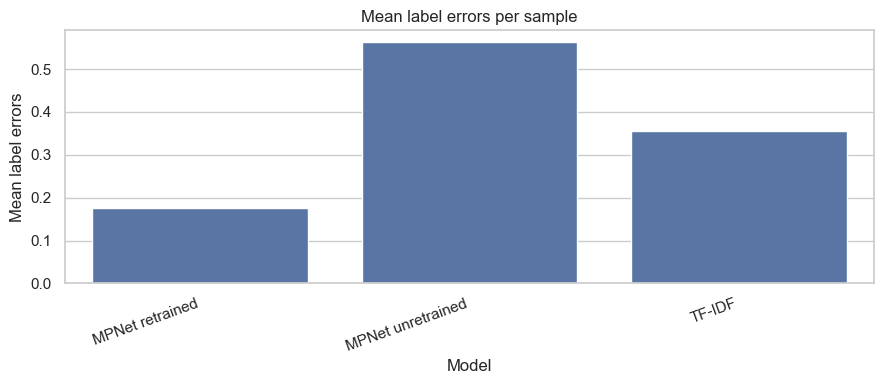

In [33]:
plt.figure(figsize=(9, 4))
sns.barplot(data=case_summary, x="model", y="mean_label_errors")
plt.title("Mean label errors per sample")
plt.xlabel("Model")
plt.ylabel("Mean label errors")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.savefig(FINAL_OUTPUT_DIR / "mean_label_errors_by_model.png", dpi=160)
plt.show()


### Best cases by model


In [34]:
best_display_cols = [
    "model",
    "source_row",
    "review_en",
    "true_aspects",
    "predicted_aspects",
    "mean_true_probability",
    "min_true_probability",
]

display(
    all_best_cases[best_display_cols]
    .sort_values(["model", "mean_true_probability"], ascending=[True, False])
    .groupby("model")
    .head(8)
    .round(4)
)


,model,source_row,review_en,true_aspects,predicted_aspects,mean_true_probability,min_true_probability
15,MPNet retrained,779,the restaurant is very clean and the ambience is very nice,ambiance,ambiance,0.9999,0.9999
16,MPNet retrained,628,it is usually a little less salty than other dishes the taste is unmatched,food,food,0.9999,0.9999
17,MPNet retrained,30,the biryani rice was fluffy and fluffy but the meat was tough,food,food,0.9998,0.9998
18,MPNet retrained,630,the biryani rice was fluffy but the meat was tough,food,food,0.9998,0.9998
19,MPNet retrained,737,the burger patty is thicker than a regular burger and because of that it is bigger,food,food,0.9997,0.9997
20,MPNet retrained,448,could not be more happy with the waiters service but the taste of the food satisfied me,"food, service","food, service",0.9983,0.9975
21,MPNet retrained,211,the taste is bad and the service is even worse,"food, service","food, service",0.9982,0.9975
22,MPNet retrained,65,their service is great and food quality is good,"food, service","food, service",0.9979,0.9971
0,MPNet unretrained,628,it is usually a little less salty than other dishes the taste is unmatched,food,food,1.0000,1.0000
1,MPNet unretrained,31,as for the beef the test was very good but the name kalabuna was not right,food,food,0.9999,0.9999


### Worst cases by model


In [35]:
worst_display_cols = [
    "model",
    "source_row",
    "review_en",
    "true_aspects",
    "predicted_aspects",
    "label_error_count",
    "false_positive_aspects",
    "false_negative_aspects",
    "max_wrong_probability",
    "mean_true_probability",
]

display(
    all_worst_cases[worst_display_cols]
    .sort_values(
        ["model", "label_error_count", "max_wrong_probability"],
        ascending=[True, False, False],
    )
    .groupby("model")
    .head(8)
    .round(4)
)


,model,source_row,review_en,true_aspects,predicted_aspects,label_error_count,false_positive_aspects,false_negative_aspects,max_wrong_probability,mean_true_probability
15,MPNet retrained,260,a restaurant and location is also very good to eat a full stomach with less money,"price, miscellaneous","food, price, ambiance",3,"food, ambiance",miscellaneous,0.3476,0.6786
16,MPNet retrained,424,the food here tastes a little better but nothing else is quite customerfriendly,"food, miscellaneous","food, service",2,service,miscellaneous,0.9928,0.5399
17,MPNet retrained,599,the pizza was delicious but the experience was horrible,"food, miscellaneous","food, service",2,service,miscellaneous,0.9719,0.6393
18,MPNet retrained,451,this restaurant is being cooked by foreign cooks and hence the price of the food is a bit high,"price, miscellaneous","food, price",2,food,miscellaneous,0.6350,0.5547
19,MPNet retrained,569,they are giving free toys to children which is good for marketing but the price of food is high and the price of toys is being collected,"price, miscellaneous","food, price",2,food,miscellaneous,0.5825,0.5511
20,MPNet retrained,593,food of normal price is very scarce here and they are not treating all the customers well,"price, service","food, price",2,food,service,0.4316,0.6992
21,MPNet retrained,365,food prices are lower than other nearby places but the food is very expensive,price,"price, miscellaneous",1,miscellaneous,None,0.9214,0.9974
22,MPNet retrained,76,the restaurant is small but expensive,"price, ambiance","price, ambiance, miscellaneous",1,miscellaneous,None,0.9151,0.9743
0,MPNet unretrained,532,from today it is my favorite restaurant because the service here is very bad and the price of everything is very high,"price, service","food, service, miscellaneous",3,"food, miscellaneous",price,0.6898,0.4914
1,MPNet unretrained,568,it is necessary to sell the land and go here to eat the price of food is so high but everyone goes here to get the touch of a good environment,"price, ambiance","food, price, miscellaneous",3,"food, miscellaneous",ambiance,0.6466,0.7416


### How To Read These Cases

- High-confidence best cases show the patterns each model handles reliably.
- Worst cases with many false positives indicate over-prediction.
- Worst cases with many false negatives indicate missed aspects.
- For this project, inspect `miscellaneous` mistakes first because it is the rarest and weakest class.
